In [1]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt

In [2]:
def kinetic_energy_mels(i, j, dx):
    return np.where(
        i==j,
        np.pi ** 2 / (6 * dx ** 2),
        (-1.0) ** (i_min_j := i - j) / (dx ** 2 * i_min_j **2),
    )

In [3]:
grid = np.linspace(-10, 10, 201)
dx = np.abs(grid[1] - grid[0])
inds=np.arange(len(grid))
potential = lambda x, omega=1: 0.5 * omega **2 * x ** 2

In [4]:
t = kinetic_energy_mels(inds[:, None], inds[None, :], dx)

/tmp/ipykernel_9848/1501254881.py:5: RuntimeWarning: divide by zero encountered in divide
  (-1.0) ** (i_min_j := i - j) / (dx ** 2 * i_min_j **2),


In [5]:
h = t + np.diag(potential(grid))

In [6]:
eps, C = scipy.linalg.eigh(h)

In [7]:
eps[:20]

array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
       11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5])

In [8]:
def shielded_coulomb(x_1, x_2, kappa=1, a=0.01):
    return kappa / np.sqrt((x_1-x_2)**2+a**2)

In [9]:
class HCImag:
    def __init__(self, x_min, x_max, num_dvr, potential):
        self.grid = np.linspace(x_min, x_max, num_dvr)
        self.dx=np.abs(self.grid[1]-self.grid[0])
        self.inds = np.arange(len(self.grid))
        self.potential = potential
        self.h = (
            kinetic_energy_mels(self.inds[:, None], self.inds[None, :], self.dx)
            +np.diag(self.potential(self.grid))
        )

    def __call__(self, t, c):
        C = c.reshape(self.h.shape[1], -1)
        return (-self.h @ C).ravel()

In [10]:
class RK4:
    def __init__(self, rhs, y0, t0):
        self.rhs = rhs
        self.y = y0
        self.t = t0

    def integrate(self, t):
        dt = t - self.t

        k1 = self.rhs(self.t, self.y)
        k2 = self.rhs(self.t + dt / 2, self.y + dt * k1 / 2)
        k3 = self.rhs(self.t + dt / 2, self.y + dt * k2 / 2)
        k4 = self.rhs(self.t + dt, self.y + dt * k3)

        self.y += 1 / 6 * (k1 + 2 * k2 + 2 * k3 + k4) * dt
        self.t += dt

        return self.t, self.y

In [11]:
t_0 = 0
c_0 = np.ones(len(inds))/np.sqrt(len(inds) * dx)
assert abs(np.dot(c_0, c_0) * dx - 1) < 1e-12

hc_imag = HCImag(grid[0], grid[-1], len(grid), potential)


/tmp/ipykernel_9848/1501254881.py:5: RuntimeWarning: divide by zero encountered in divide
  (-1.0) ** (i_min_j := i - j) / (dx ** 2 * i_min_j **2),


In [12]:
rk4 = RK4(hc_imag, c_0, t_0)

num_steps = 1000
dt = 1e-3
energies = np.zeros(num_steps)

for i in range(num_steps):
    energies[i] = rk4.y.T @ (hc_imag(rk4.t, rk4.y) * dx)
    rk4.integrate(rk4.t + dt)
    rk4.y = rk4.y/np.sqrt(rk4.y@rk4.y * dx)


In [13]:
print(energies)

[-17.52303818 -16.88158667 -16.30811539 -15.78072104 -15.28709306
 -14.81998151 -14.37490492 -13.94895363 -13.54014345 -13.14705431
 -12.76862112 -12.40400868 -12.05253454 -11.71362004 -11.38675862
 -11.07149474 -10.76740974 -10.47411224 -10.19123149  -9.91841285
  -9.65531465  -9.40160612  -9.15696587  -8.92108102  -8.69364655
  -8.47436497  -8.26294611  -8.05910701  -7.86257191  -7.67307227
  -7.4903468   -7.3141415   -7.1442097   -6.98031209  -6.82221673
  -6.66969901  -6.52254169  -6.38053477  -6.2434755   -6.11116823
  -5.98342435  -5.86006217  -5.74090676  -5.62578984  -5.51454963
  -5.40703063  -5.30308355  -5.20256504  -5.10533758  -5.01126925
  -4.92023359  -4.83210939  -4.74678053  -4.66413576  -4.58406855
  -4.50647692  -4.43126323  -4.35833405  -4.28759995  -4.21897538
  -4.15237847  -4.08773091  -4.02495777  -3.96398739  -3.90475119
  -3.8471836   -3.79122185  -3.73680592  -3.68387838  -3.63238426
  -3.58227099  -3.53348824  -3.48598783  -3.43972368  -3.39465163
  -3.35072

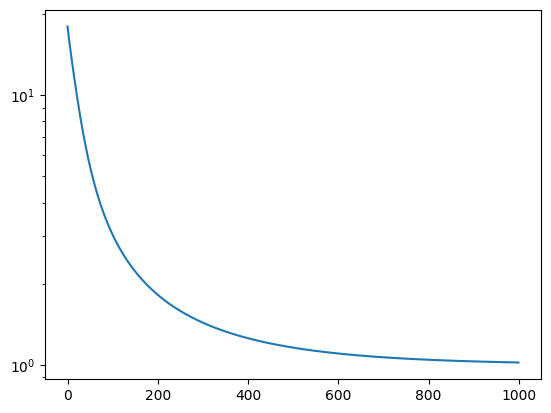

In [14]:
plt.semilogy(np.abs(energies-0.5))
plt.show()

In [15]:
class FCImag:
    def __init__(self, num_hf, num_occ, x_min, x_max, num_dvr, potential, kappa = 1):
        self.num_hf = num_hf
        self.num_occ = num_occ
        assert num_occ % 2 == 0
        self.o = slice(0, num_occ//2)
        self.grid = np.linspace(x_min, x_max, num_dvr)
        self.dx=np.abs(self.grid[1]-self.grid[0])
        self.inds = np.arange(len(self.grid))
        self.potential = potential
        self.h = (
            kinetic_energy_mels(self.inds[:, None], self.inds[None, :], self.dx)
            +np.diag(self.potential(self.grid))
        )
        self.u = shielded_coulomb(self.grid[:, None], self.grid[None, :], kappa=kappa)

    def __call__(self, t, c):
        C = c.reshape(self.h.shape[1], self.num_hf)
        D = np.einsum("pi, qi -> pq", C, C.conj())
        u_d = np.einsum("pq, q, -> p", self.u, np.diag(D))
        u_ex = self.u * D
        f = self.h + 2*np.diag(u_d) - u_ex
        return (-f @ C).ravel()

In [16]:
rk4 = RK4(hc_imag, c_0, t_0)

num_steps = 1000
dt = 1e-3
energies = np.zeros(num_steps)

for i in range(num_steps):
    energies[i] = rk4.y.T @ (hc_imag(rk4.t, rk4.y) * dx)
    rk4.integrate(rk4.t + dt)
    rk4.y = rk4.y/np.sqrt(rk4.y@rk4.y * dx)
